## Benchmarks

In [1]:
import sph_cupy
import sph # baseline
import sph_multiprocessing

done
True
True


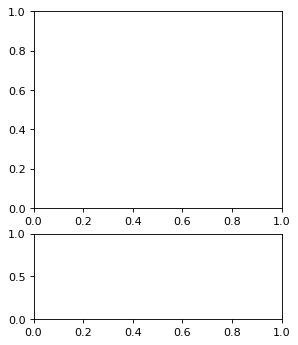

In [2]:
# Vailidation
import numpy as np

pos, vel = sph.main(400)
print("done")
mp_pos, mp_vel = sph_multiprocessing.main(400)

print(np.array_equal(pos, mp_pos))
print(np.array_equal(vel, mp_vel))

In [3]:
import matplotlib.pyplot as plt

def benchmark(funcs, Ns):
    benchmark_data = {}
    for func in funcs:
        ts_avg = []
        for n in Ns:
            t = %timeit -o func(n)
            ts_avg.append(t.average)
        
        benchmark_data[func.__module__] = ts_avg
        
    return benchmark_data

def plot_benchmarks(benchmark_data, Ns):
    plt.close("all")
    plt.title("Benchmarks")
    for t in benchmark_data:
        plt.plot(Ns, benchmark_data[t], marker='o', label=t)
        plt.xlabel("Number of particles")
        plt.legend()
        plt.grid(True)
        plt.ylabel("Average runtime")
    plt.show()


In [ ]:
import time

t1 = time.time()
sph.main(1000)
print(f"sph time: {time.time() - t1}")

t1 = time.time()
sph_multiprocessing.main(1000)
print(f"sph mp time: {time.time() - t1}")

384 ms ± 15.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
384 ms ± 13.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


/home/isakf/dev/kth/optimizations-of-sph/sph_cupy.py:195: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(4, 5), dpi=80)


340 ms ± 11.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
314 ms ± 5.75 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.25 s ± 432 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.63 s ± 130 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.38 s ± 91.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.11 s ± 145 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.46 s ± 177 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


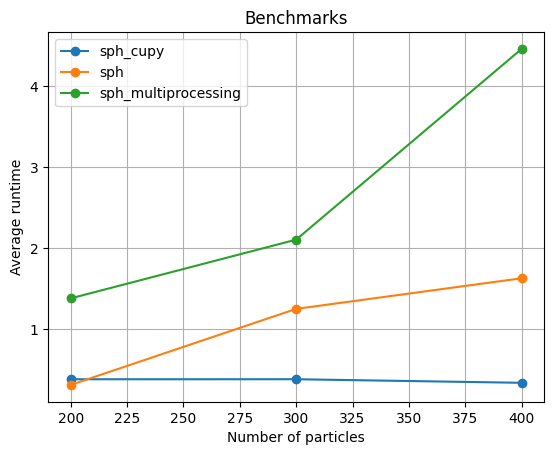

In [ ]:
funcs = [sph_cupy.main, sph.main, sph_multiprocessing.main]
Ns = [200, 300, 400]

benchmarks = benchmark(funcs, Ns)
plot_benchmarks(benchmarks, Ns)